In [2]:
from models import Discriminator, UNet, Generator
from datasets import ImageDataset,tophat
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torch
import torchvision
from skimage import io, morphology
import matplotlib.pyplot as plt
import numpy as np
from models import UNet,Generator
from PIL import Image,ImageOps
from tqdm import tqdm
import random
import cv2
from utils import fusion_predict, make_mask, merge_ckpts, denorm, clear_mask,out2mask,batch2pil
from pathlib import Path
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


20140421_00040522_8


(<matplotlib.axes._subplots.AxesSubplot at 0x7fc4f0221350>,
 <matplotlib.image.AxesImage at 0x7fc4f0190490>)

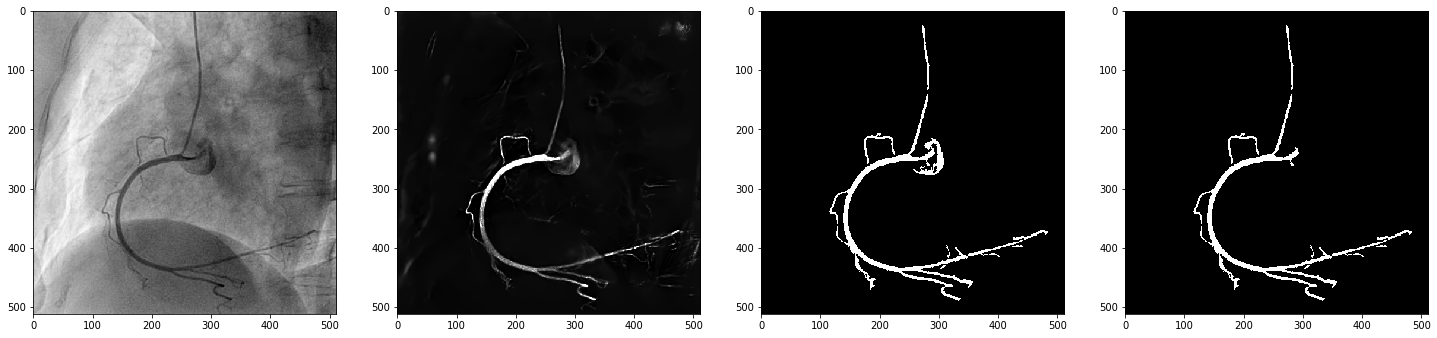

In [73]:
sz = 512
tfmc1 = T.Compose([
    T.Resize(sz),
    T.Lambda(lambda img: tophat(img,50)),
    T.ToTensor(),
    T.Normalize((0.5),(0.5))
])

tfmc2 = T.Compose([
    T.Resize(sz),
    T.ToTensor(),
    T.Normalize((0.5),(0.5))
])


ds1 = ImageDataset('datasets/cycledsa_v46/', size=sz, unaligned=False, mode='test', transform=tfmc1)
ds2 = ImageDataset('datasets/cycledsa_v46/', size=sz, unaligned=False, mode='test', transform=tfmc2)
# ds1 = ImageDataset('./', size=sz, unaligned=False, mode='eval50', transform=tfmc1)
# ds2 = ImageDataset('./', size=sz, unaligned=False, mode='eval50', transform=tfmc2)
# ds1 = ImageDataset('./', size=sz, unaligned=False, mode='dsa_sample', transform=tfmc1)
# ds2 = ImageDataset('./', size=sz, unaligned=False, mode='dsa_sample', transform=tfmc2)


netG_B2A = UNet(1, 1, 32, bilinear=True)
netG_B2A = torch.nn.DataParallel(netG_B2A)
ckpts = [
        'mlruns/4/ebb5a026a1264aa0a6b207adab540040/last.ckpt', # lr1e5
#         'mlruns/4/da9110cc64c24cb08fc23984966bc62a/056.ckpt', # rot
#      'mlruns/8/0e319c046cb243a79174e0548dcf572d/020.ckpt', # rot对齐
]


idx = 76

# eval
x1 = ds1[idx]['B']
x2 = ds2[idx]['B']
fname = ds1.files_B[idx]
fname = Path(fname).name.split('.')[0]
print(fname)

B1,out1 = fusion_predict(netG_B2A, ckpts, x1, multiangle=False, denoise=3, size=sz, cutoff=0.4, pad=0, netE=True)
B2,out2 = fusion_predict(netG_B2A, ckpts, x2, multiangle=False, denoise=3, size=sz, cutoff=0.4, pad=0, netE=True)
mask1 = make_mask(out1,remove_size=0, local_kernel=25, hole_max_size=50)
mask2 = make_mask(out2,remove_size=0, local_kernel=25, hole_max_size=50)

out_merge = Image.fromarray(np.expand_dims(np.max(np.concatenate((np.array(out1),np.array(out2)),axis=2),axis=2),2).repeat(3,2))

mask_merge = make_mask(out_merge,remove_size=2000, local_kernel=21, hole_max_size=50)
out_merge = T.functional.adjust_gamma(out_merge,2.5)
mask_cld = clear_mask(mask_merge)



plt.figure(figsize=(25,25))
plt.subplot(141),plt.imshow(B2)
plt.subplot(142),plt.imshow(out_merge)
plt.subplot(143),plt.imshow(mask_merge,cmap='gray')
plt.subplot(144),plt.imshow(mask_cld,cmap='gray')